# Import dataset

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap
import math
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
path = kagglehub.dataset_download("ivivan/real-time-water-quality-data")

print("Path to dataset files:", path, "\n")

file_names = os.listdir(path)

print("Files in the dataset directory:")
for file_name in file_names:
    print(file_name)

100%|██████████| 2.84M/2.84M [00:00<00:00, 40.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ivivan/real-time-water-quality-data/versions/2 

Files in the dataset directory:
sandy_ck_homebush_joined.csv
Pioneer_Dumbleton_joined.csv
Proserpine_river_glen_isla_joined.csv
Plane_ck_sucrogen_joined.csv
Tully_river_euramo_joined.csv
Tully_River_Tully_Gorge_National_Park_joined.csv
Johnstone_river_innisfail_joined.csv
Mulgrave_river_deeral_joined.csv
russell_river_east_russell_joined.csv
Johnstone_river_coquette_point_joined.csv
sandy_ck_sorbellos_road_joined.csv


In [ ]:
df = pd.read_csv(os.path.join(path, "Mulgrave_river_deeral_joined.csv"))
df.head()

,Timestamp,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
0,2016-12-08T13:00:00,-42.611000,NaN,NaN,NaN,NaN,NaN,3,12
1,2016-12-08T14:00:00,-48.305000,0.0,NaN,NaN,0.0,10.303333,3,12
2,2016-12-08T15:00:00,-49.874333,0.0,NaN,NaN,0.0,10.602000,3,12
3,2016-12-08T16:00:00,-35.325000,0.0,NaN,NaN,0.0,10.788000,3,12
4,2016-12-08T17:00:00,24.020167,0.0,NaN,NaN,0.0,10.820000,3,12


The dataset used in this study was obtained from a water quality monitoring station located at Mulgrave River – Deeral, in North Queensland, Australia. The monitoring station continuously records several hydrological and water quality parameters that are important for understanding river system dynamics and environmental conditions.

The dataset consists of hourly observations collected over a period of approximately 3 years and 4 months, spanning from 8 December 2016 13:00:00 to 1 April 2020 23:00:00. In total, the dataset contains 29,051 time-stamped records. Each record represents measurements collected at a one-hour interval.

The variables included in the dataset represent both hydrological conditions and water quality indicators. The available parameters are:

* Q – River discharge or flow rate

* Conductivity – Electrical conductivity of the water, indicating dissolved ion concentration

* NO₃ – Nitrate concentration (target variable in this study)

* Temp – Water temperature

* Turbidity – Water turbidity representing suspended particles

* Level – River water level

These variables provide complementary information about hydrological processes and water quality dynamics in the river system.

# Overview

In [ ]:
print(f"Number of rows: {len(df)}")
print(f"{df.columns.size} Columns: {df.columns.tolist()}")

# time frequency
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_sorted = df.sort_values('Timestamp')
freq = pd.infer_freq(df_sorted['Timestamp'])

if freq:
    print(f"Inferred time frequency: {freq}")
else:
    print("Could not infer time frequency.")

min_timestamp = df_sorted['Timestamp'].min()
max_timestamp = df_sorted['Timestamp'].max()

print(f"Min Timestamp: {min_timestamp}")
print(f"Max Timestamp: {max_timestamp}")

# Convert to datetime objects for relativedelta
min_dt = min_timestamp.to_pydatetime()
max_dt = max_timestamp.to_pydatetime()

# Calculate the difference using relativedelta
delta = relativedelta(max_dt, min_dt)

print(f"Time span: {delta.years} years, {delta.months} months, {delta.days} days, {delta.hours} hours")

Number of rows: 29051
9 Columns: ['Timestamp', 'Q', 'Conductivity', 'NO3', 'Temp', 'Turbidity', 'Level', 'Dayofweek', 'Month']
Inferred time frequency: h
Min Timestamp: 2016-12-08 13:00:00
Max Timestamp: 2020-04-01 23:00:00
Time span: 3 years, 3 months, 24 days, 10 hours


# Missing Data

In [ ]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df.set_index('Timestamp', inplace=True)

print(f"\n--- Missing values ---")
missing_counts = df.isnull().sum()
print("Counts:")
print(missing_counts)
print("\nPercentages (%):")
missing_percentages = ((missing_counts / len(df)) * 100).round(2)
print(missing_percentages)


--- Missing values ---
Counts:
Q                9642
Conductivity     7854
NO3             18987
Temp            17269
Turbidity        7854
Level             273
Dayofweek           0
Month               0
dtype: int64

Percentages (%):
Q               33.19
Conductivity    27.04
NO3             65.36
Temp            59.44
Turbidity       27.04
Level            0.94
Dayofweek        0.00
Month            0.00
dtype: float64


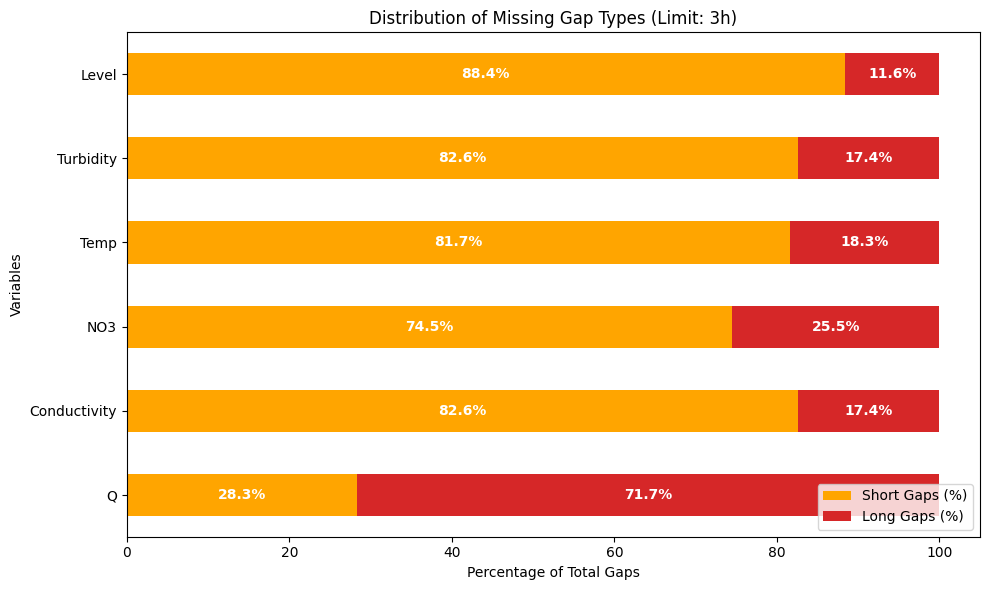

In [ ]:
def gap_length_summary(series):
    is_nan = series.isna()
    groups = (is_nan != is_nan.shift()).cumsum()
    return series[is_nan].groupby(groups).size()

# Define the limit: 3 missing timestamps (3 hours)
short_gap_limit = 3

gap_stats = []

for col in df.columns:
    gaps = gap_length_summary(df[col])
    if len(gaps) > 0:
        short = (gaps <= short_gap_limit).sum()
        long = (gaps > short_gap_limit).sum()
        total = len(gaps)
        gap_stats.append({
            'Variable': col,
            'Short Gaps (%)': (short / total) * 100,
            'Long Gaps (%)': (long / total) * 100
        })

# Create a DataFrame for visualization
gap_df = pd.DataFrame(gap_stats).set_index('Variable')

# Plotting
ax = gap_df.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#ffa500', '#d62728'])
plt.title(f'Distribution of Missing Gap Types (Limit: {short_gap_limit}h)')
plt.xlabel('Percentage of Total Gaps')
plt.ylabel('Variables')
plt.legend(loc='lower right')

# Add percentage labels on the bars
for p in ax.patches:
    width = p.get_width()
    if width > 5: # Only show label if segment is large enough
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2,
                f'{width:.1f}%', va='center', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

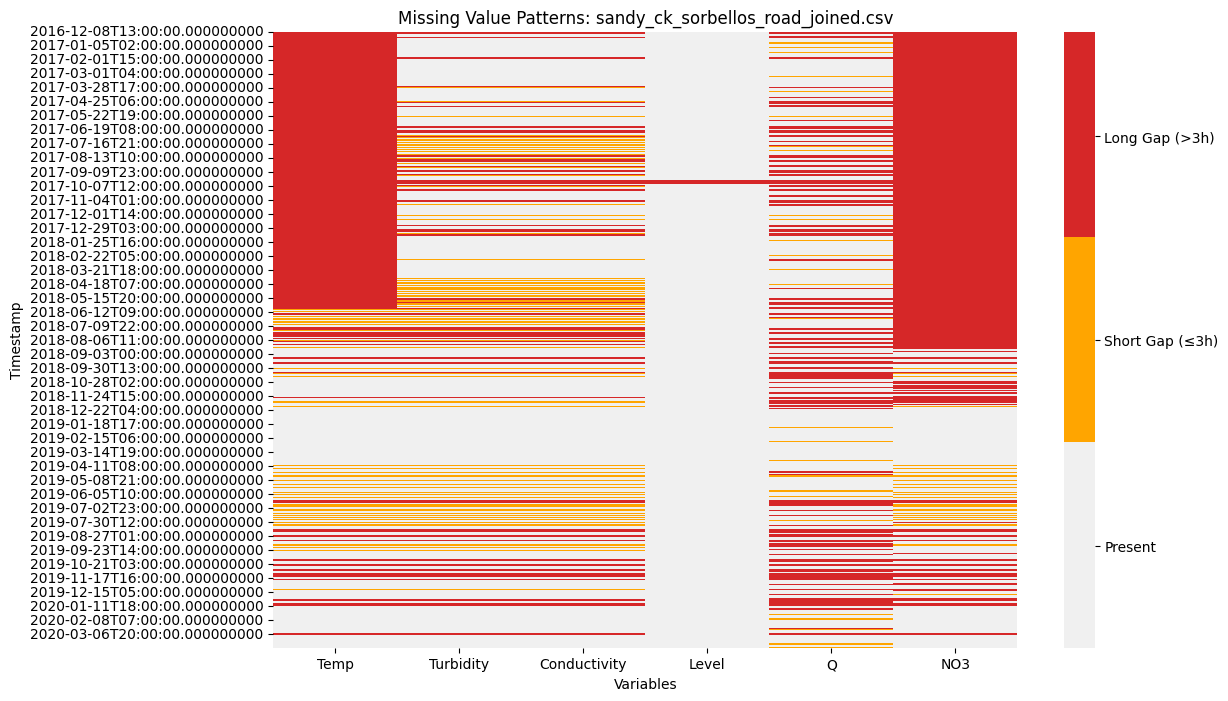

In [ ]:
variables_to_plot = ['Temp', 'Turbidity', 'Conductivity', 'Level', 'Q', 'NO3']
# Prepare a categorical dataframe for visualization
# 0: Present, 1: Short Gap (<=3), 2: Long Gap (>3)
vis_df = pd.DataFrame(0, index=df.index, columns=variables_to_plot)

for col in variables_to_plot:
    is_missing = df[col].isnull()
    if not is_missing.any():
        continue

    # Identify groups of consecutive missing values
    groups = (is_missing != is_missing.shift()).cumsum()
    gap_lengths = is_missing.groupby(groups).transform('size')

    # Mark short gaps as 1 and long gaps as 2
    vis_df.loc[is_missing & (gap_lengths <= short_gap_limit), col] = 1
    vis_df.loc[is_missing & (gap_lengths > short_gap_limit), col] = 2

plt.figure(figsize=(12, 8))
# Custom colormap: 0=lightgrey (present), 1=orange (short gap), 2=red (long gap)
cmap = ListedColormap(['#f0f0f0', '#ffa500', '#d62728'])

ax = sns.heatmap(vis_df, cmap=cmap, cbar=True)

# Adjust colorbar labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0.33, 1, 1.66])
colorbar.set_ticklabels(['Present', f'Short Gap (≤{short_gap_limit}h)', f'Long Gap (>{short_gap_limit}h)'])

plt.title(f'Missing Value Patterns: {file_name}')
plt.xlabel('Variables')
plt.ylabel('Timestamp')
plt.show()

# Statistical Summary

In [ ]:
df.describe()

,Q,Conductivity,NO3,Temp,Turbidity,Level,Dayofweek,Month
count,19409.000000,21197.000000,10064.000000,11782.000000,21197.000000,28778.000000,29051.000000,29051.000000
mean,53.208440,2551.276278,0.151926,25.844899,9.739699,10.343030,3.000000,6.289766
std,112.819638,6078.569621,0.097275,2.859455,49.238263,0.595742,2.000482,3.588261
min,-157.724333,0.000000,0.001000,18.770000,0.000000,9.150000,0.000000,1.000000
25%,-8.444000,56.600000,0.068000,23.770000,2.240000,9.926667,1.000000,3.000000
50%,37.335500,91.900000,0.145000,25.870000,3.450000,10.265000,3.000000,6.000000
75%,79.556167,1322.410000,0.221000,28.200000,6.660000,10.674286,5.000000,9.000000
max,1067.799333,48453.100000,0.486000,32.740000,5734.270000,15.638750,6.000000,12.000000


# Time-series Visualisation

Generating time series plots for files with all specified variables:


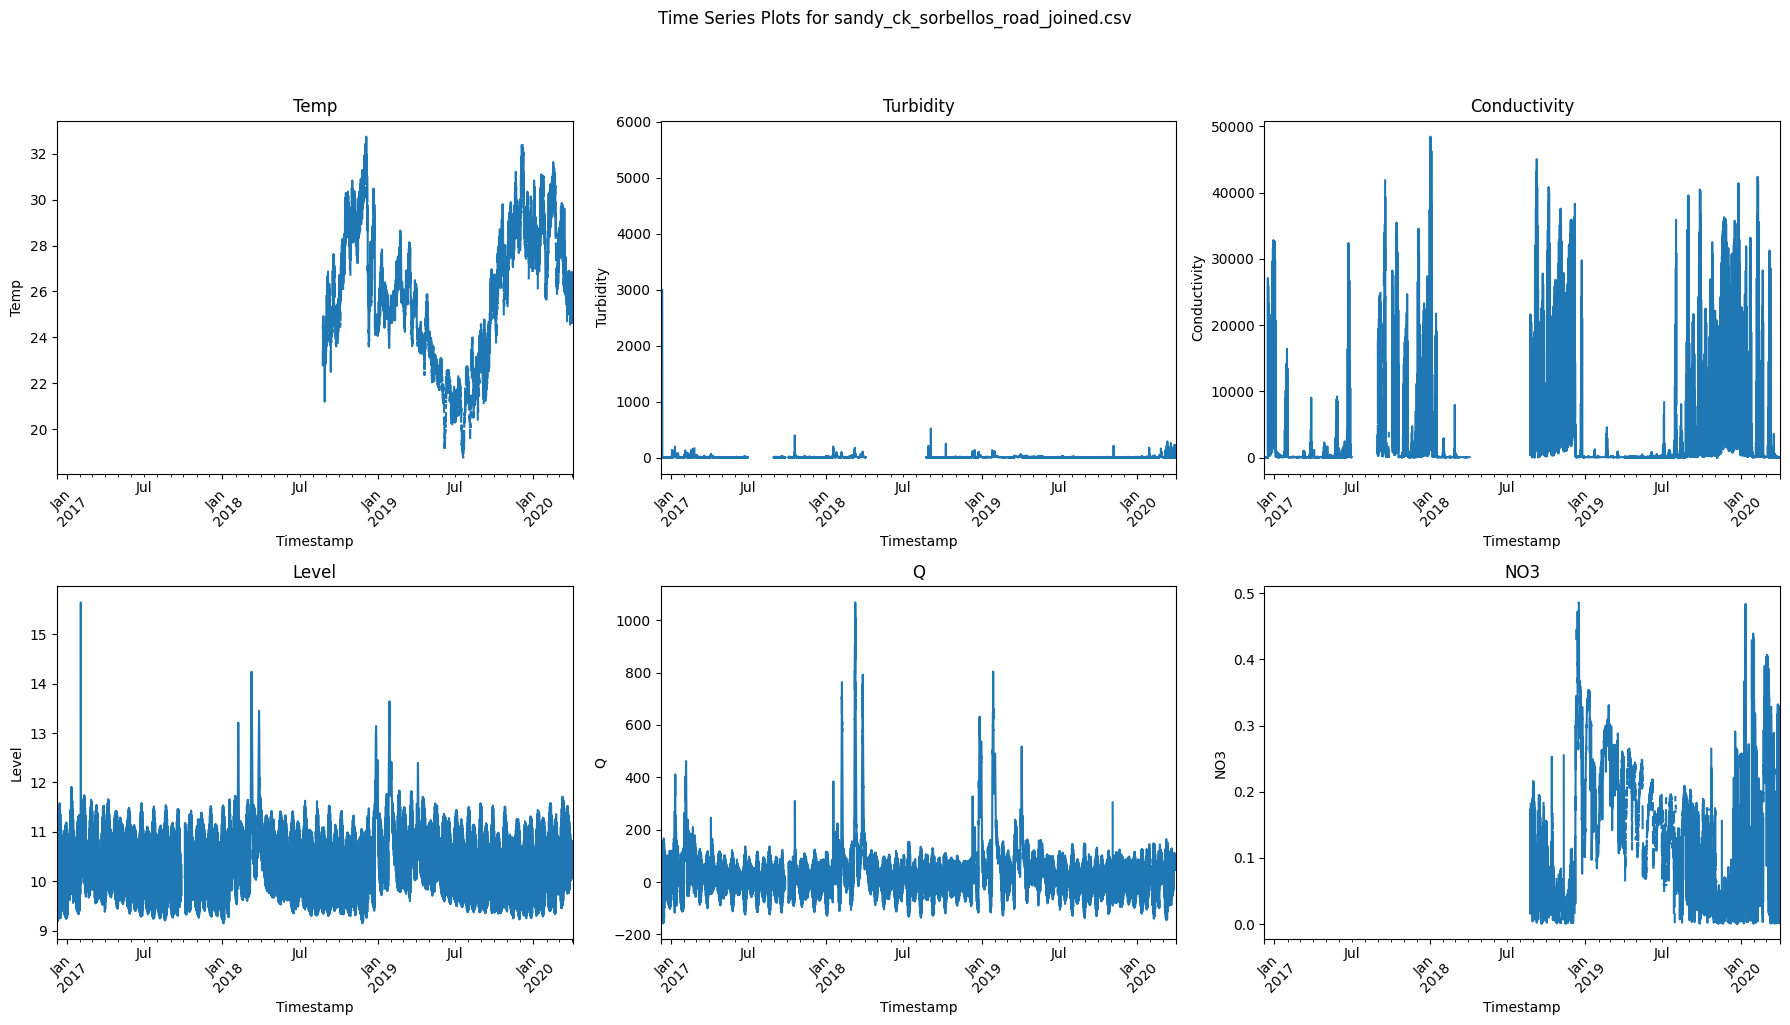

In [ ]:
print("Generating time series plots for files with all specified variables:")

# Check if all variables in variables_to_plot are in the current dataframe's columns
if all(variable in df.columns for variable in variables_to_plot):
    num_variables = len(variables_to_plot)
    num_cols = 3
    num_rows = 2

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), squeeze=False)
    fig.suptitle(f'Time Series Plots for {file_name}', y=1.02) # Add a title for the entire figure

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    for i, variable in enumerate(variables_to_plot):
        ax = axes[i]
        df[variable].plot(ax=ax)
        ax.set_title(variable)
        ax.set_xlabel('Timestamp')
        ax.set_ylabel(variable)
        ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels for readability

    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent titles overlapping
    plt.show()

# Data Distribution

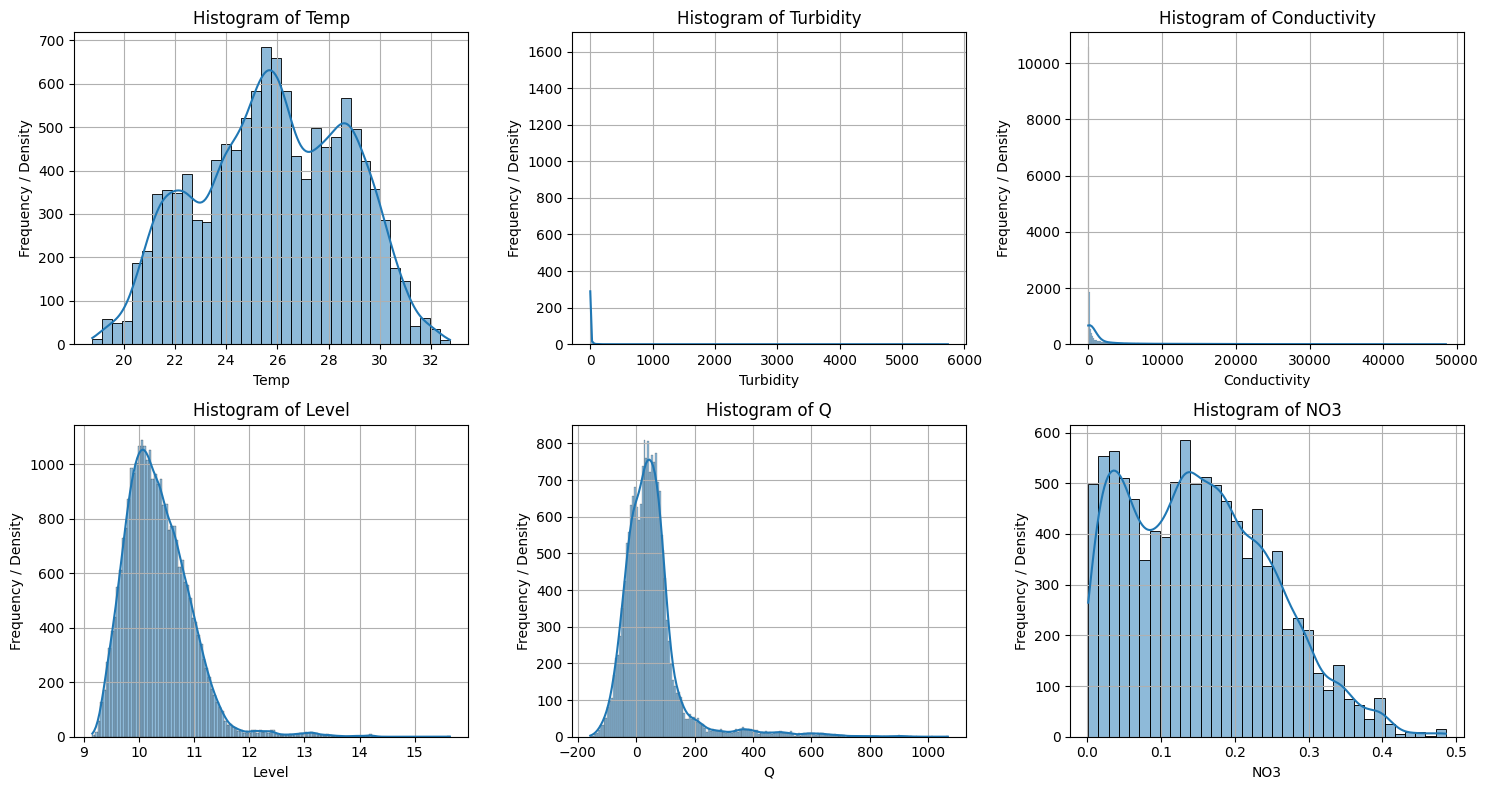

In [ ]:
# Histograms for the selected columns
num_variables = len(variables_to_plot)
num_rows = 2
num_cols = math.ceil(num_variables / num_rows)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables_to_plot):
    if col in df.columns:
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency / Density')
        axes[i].grid(True)
    else:
        print(f"Column '{col}' not found.")

# Hide any unused subplots if num_variables is not a multiple of num_cols
for j in range(num_variables, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Seasonal Pattern

<Axes: xlabel='Timestamp'>

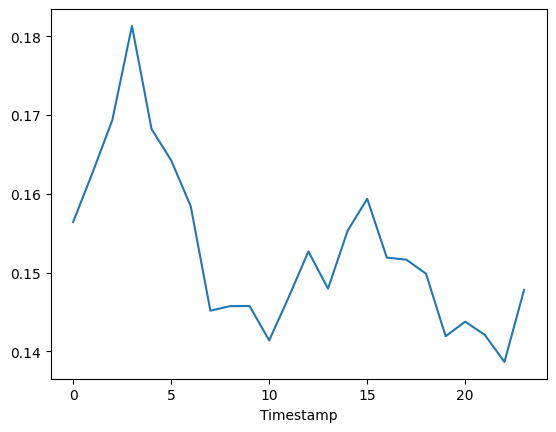

In [ ]:
df_clean = df.dropna(subset=["NO3"])

# hourly pattern
df_clean.groupby(df_clean.index.hour)["NO3"].mean().plot()

<Axes: xlabel='Timestamp'>

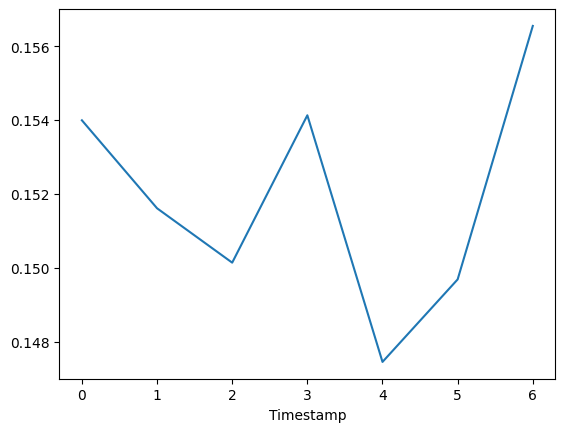

In [ ]:
# weekly pattern
df_clean.groupby(df_clean.index.dayofweek)["NO3"].mean().plot()

<Axes: xlabel='Timestamp'>

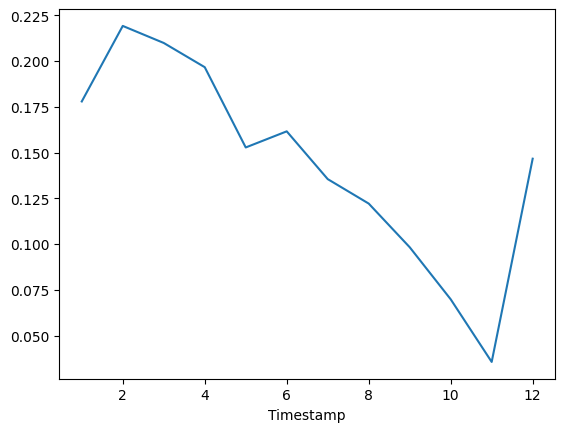

In [ ]:
# montly pattern
df_clean.groupby(df_clean.index.month)["NO3"].mean().plot()

# Autocorrelation Analysis

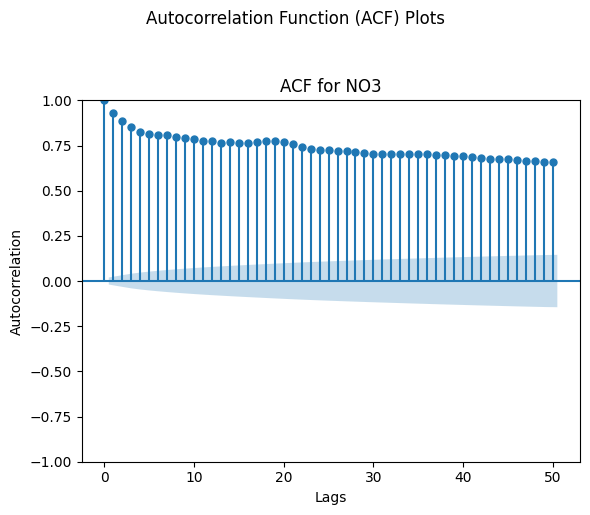

In [ ]:
target_variables = ["NO3"]

# Select only the target variables that exist in the current dataframe
target_variables_in_df = [variable for variable in target_variables if variable in df.columns]
num_target_variables = len(target_variables_in_df)

if num_target_variables > 0:
    # Determine the number of rows and columns for subplots
    num_cols = 1
    num_rows = math.ceil(num_target_variables / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), squeeze=False)
    fig.suptitle(f'Autocorrelation Function (ACF) Plots', y=1.02) # Add a title for the entire figure

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    for i, variable in enumerate(target_variables_in_df):
        ax = axes[i]
        # Drop missing values for ACF calculation
        plot_acf(df[variable].dropna(), ax=ax, lags=50)
        ax.set_title(f'ACF for {variable}')
        ax.set_xlabel('Lags')
        ax.set_ylabel('Autocorrelation')

    # Hide any unused subplots
    for j in range(num_target_variables, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout
    plt.show()